#Gear ratio Calculator

This script calculates the ideal gear ratio for a dual pull boom deployment mechanism
The equations that are implmented are from Advanced Dual-Pull Mechanism for Deployable Spacecraft Booms, by Firth and Pankow
The paper is obtainable here https://www.researchgate.net/publication/329423056_Advanced_Dual-Pull_Mechanism_for_Deployable_Spacecraft_Booms

To run this script you need the thickness of the boom, the thickness of the tape, the length of the boom,
hub core radius, pinion radius 

In [13]:
import math
from scipy.optimize import brentq
import numpy as np
import matplotlib.pyplot as plt

#Helper functions

In [14]:
# This function returns the arc length of the boom as a function of theta p
def boom_length(theta_p, tape_thickness, theta_p0, s_p0, target_s):
    s = (tape_thickness / (4*math.pi)) * ((theta_p + theta_p0) * math.sqrt(1 + (theta_p + theta_p0)**2) + math.asinh(theta_p + theta_p0)) - s_p0
    # Bring function to 0 at target_s
    s = s - target_s
    return s 

# This functions returns the arc length of the boom as a function of theta h 
def hub_length(theta_h,tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s):
    s = s_max - ((tape_thickness+boom_thickness) / (4*math.pi)) * ((theta_h + theta_h0) * math.sqrt(1 + (theta_h + theta_h0)**2) + math.asinh(theta_h + theta_h0)) + s_h0
    # No need to bring this function to 0 at the target since it already is 
    return s - (s_max - target_s)  # find theta_h where remaining == s_max - target_s


def calculate_gear_ratio(boom_thickness, tape_thickness, max_boom_length, initally_coiled_tape_length, initally_coiled_tape_angle, initally_coiled_boom_length, initally_coiled_boom_angle):
    
    # Rename variables to equation parameters
    s_max = max_boom_length
    s_p0 = initally_coiled_tape_length
    theta_p0 = initally_coiled_tape_angle
    s_h0 = initally_coiled_boom_length
    theta_h0 = initally_coiled_boom_angle

    # Set target s to the max boom length, we want to find the gear ratio that allows us to reach the max boom length, 
    # if we want to reproduce the graphs of the study I kept these variables separate in the actual arc length functions
    target_s = s_max

    # Solve equation 3 for the max theta p, the max amount of radians the pinion turns
    # set some bounds for theta p, 
    theta_p_min = 0
    theta_p_cap = 5000
    max_theta_p = brentq(boom_length, theta_p_min, theta_p_cap, args=(tape_thickness, theta_p0, s_p0, target_s))

    # Solve equation 4 for the max theta h, the max amount of radians the hub turns
    # set some bounds for theta h,
    theta_h_min = 0 
    theta_h_cap = 5000
    max_theta_h = brentq(hub_length, theta_h_min, theta_h_cap, args=(tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s))

    # Calculate the gear ratio, the ratio of the angle the pinion turns to the angle the hub turns
    gear_ratio = max_theta_p / max_theta_h

    return gear_ratio, max_theta_p, max_theta_h

Initial Values

In [15]:
# Note on units: Since archimedes spiral is purely geometric, we just need to keep the same units for all the parameters, so we can use mm for all lengths and radians for angles, the gear ratio is unitless so it does not matter.
boom_thickness = 0.1 # in mm
tape_thickness = 0.06 # in mm
max_boom_length = 10000 # in mm (10m)

# Set these to 0 for now, put actual values later
initally_coiled_tape_length = 0 # in mm
initally_coiled_tape_angle = 0 # in radians
initally_coiled_boom_length = 0 # in mm
initally_coiled_boom_angle = 0 # in radians


In [16]:
# Rename variables to equation parameters
s_max = max_boom_length
s_p0 = initally_coiled_tape_length
theta_p0 = initally_coiled_tape_angle
s_h0 = initally_coiled_boom_length
theta_h0 = initally_coiled_boom_angle

Gear Ratio Calculation

In [17]:
calculated_gear_ratio, max_theta_p, max_theta_h = calculate_gear_ratio(boom_thickness, tape_thickness, max_boom_length, initally_coiled_tape_length, initally_coiled_tape_angle, initally_coiled_boom_length, initally_coiled_boom_angle)

print(f"Calculated gear ratio: {calculated_gear_ratio}")
print(f"Max theta p: {max_theta_p} radians")    
print(f"Max theta h: {max_theta_h} radians")

Calculated gear ratio: 1.6329981557686901
Max theta p: 1447.1995825940207 radians
Max theta h: 886.2224231433931 radians


Find the revolutions the spring needs to be able to handle

Max spring excursion: 0.047141654204398975 radians
Max spring excursion: 0.007502827292158927 revolutions


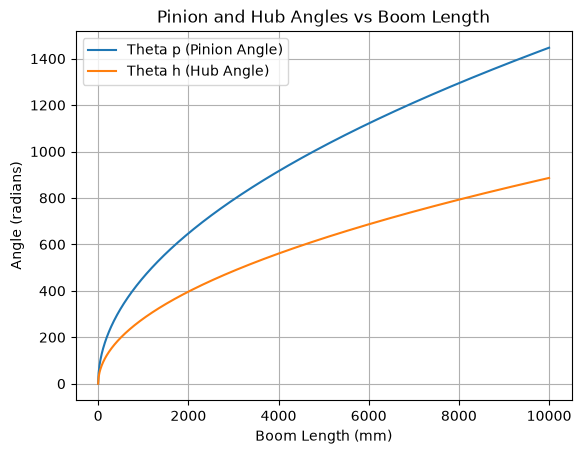

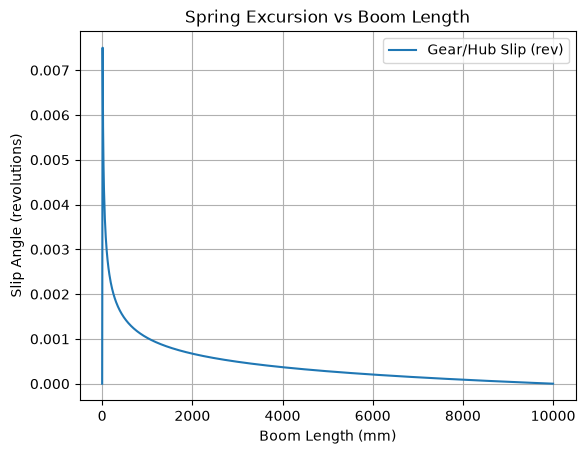

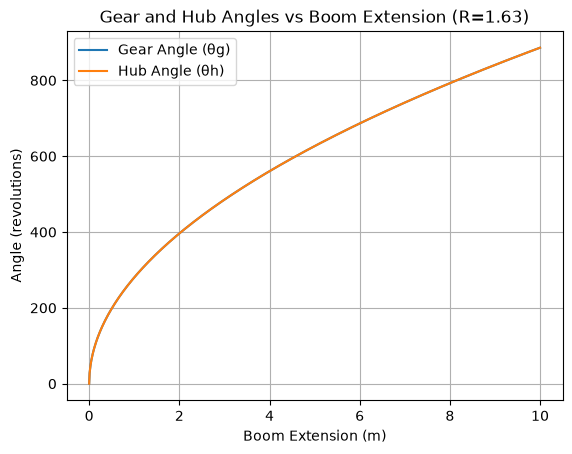

In [22]:
# To find the revolutions the spring needs to withstand, we need to calculate the difference between both gear ratios. 

# Set up samples 
arc_length = np.linspace(0, max_boom_length, 1000)
theta_h_values = []
theta_p_values = []
gear_angle_values = []
slip_angle_values = []

for target_s in arc_length:
    # Calculate the theta h and theta p values for each point on the boom length
    # Solve equation 3 for theta p
    theta_p_min = 0
    theta_p_cap = 5000
    theta_p = brentq(boom_length, theta_p_min, theta_p_cap, args=(tape_thickness, theta_p0, s_p0, target_s))
    theta_p_values.append(theta_p)

    # Solve equation 4 for the max theta h, the max amount of radians the hub turns
    # set some bounds for theta h,
    theta_h_min = 0 
    theta_h_cap = 5000
    theta_h = brentq(hub_length, theta_h_min, theta_h_cap, args=(tape_thickness, boom_thickness, theta_h0, s_h0, s_max, target_s))
    theta_h_values.append(theta_h)

    # Solve for gear angle values 
    gear_angle = theta_p / calculated_gear_ratio
    gear_angle_values.append(gear_angle)
    
    
    # Solve for the difference in hub vs gear angle. Since Theta gear - Theta hub = theta pinion / gear ratio - theta hub
    slip_angle = theta_p / calculated_gear_ratio - theta_h
    slip_angle_values.append(slip_angle)


# Find max revolutions of spring 
max_slip_radians = max(slip_angle_values)
max_slip_revolutions = max_slip_radians / (2 * math.pi)

print(f"Max spring excursion: {max_slip_radians} radians")
print(f"Max spring excursion: {max_slip_revolutions} revolutions")

# Graph the results to see the divergence of the angles as the boom length increases. 

plt.plot(arc_length, theta_p_values, label='Theta p (Pinion Angle)')
plt.plot(arc_length, theta_h_values, label='Theta h (Hub Angle)')
plt.xlabel('Boom Length (mm)')
plt.ylabel('Angle (radians)')
plt.title('Pinion and Hub Angles vs Boom Length')
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(arc_length, [s / (2 * math.pi) for s in slip_angle_values], label='Gear/Hub Slip (rev)')
plt.xlabel('Boom Length (mm)')
plt.ylabel('Slip Angle (revolutions)')
plt.title('Spring Excursion vs Boom Length')
plt.legend()
plt.grid()
plt.show()


# Check gear and hub angle converge 
plt.figure()
# plt.plot(arc_length / 1000, theta_p_values, label='Gear Angle (θp/R)')
plt.plot(arc_length / 1000, gear_angle_values, label='Gear Angle (θg)')
plt.plot(arc_length / 1000, theta_h_values, label='Hub Angle (θh)')

plt.xlabel('Boom Extension (m)')
plt.ylabel('Angle (revolutions)')
plt.title(f'Gear and Hub Angles vs Boom Extension (R={calculated_gear_ratio:.2f})')
plt.legend()
plt.grid()
plt.show()